# Digit Recognizer — ResNet with PyTorch

ResNet implementation for the Kaggle MNIST Digit Recognizer competition.  
Architecture: ResNet-18 adapted for 28×28 grayscale input.

In [7]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
import matplotlib.pyplot as plt

# Reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## Kaggle Login
Run this once per session to authenticate with Kaggle.

In [8]:
import kagglehub
kagglehub.login()

digit_recognizer_path = kagglehub.competition_download('digit-recognizer')

print('Data source import complete.')

Data source import complete.


## 1. Load Data

In [9]:
import os

# Use the path where the dataset was downloaded
TRAIN_PATH = os.path.join(digit_recognizer_path, "train.csv")
TEST_PATH  = os.path.join(digit_recognizer_path, "test.csv")

train_df = pd.read_csv(TRAIN_PATH)
test_df  = pd.read_csv(TEST_PATH)

print(f"Train shape: {train_df.shape}")
print(f"Test shape:  {test_df.shape}")
train_df.head(3)


Train shape: (42000, 785)
Test shape:  (28000, 784)


,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 2. Dataset & DataLoaders

In [10]:
class MNISTDataset(Dataset):
    """Dataset for MNIST CSV files (train with labels, test without)."""

    def __init__(self, dataframe, is_train=True, transform=None):
        self.is_train = is_train
        self.transform = transform
        if is_train:
            self.labels = torch.tensor(dataframe["label"].values, dtype=torch.long)
            self.images = dataframe.drop("label", axis=1).values.astype(np.float32)
        else:
            self.labels = None
            self.images = dataframe.values.astype(np.float32)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        # Reshape flat pixel vector to (1, 28, 28) and normalise to [0, 1]
        img = self.images[idx].reshape(1, 28, 28) / 255.0
        img = torch.from_numpy(img)
        if self.transform:
            img = self.transform(img)
        if self.is_train:
            return img, self.labels[idx]
        return img


# Augmentation for training
train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
])

BATCH_SIZE  = 64
VAL_SPLIT   = 0.1

full_dataset = MNISTDataset(train_df, is_train=True, transform=train_transform)
test_dataset = MNISTDataset(test_df,  is_train=False)

val_size   = int(len(full_dataset) * VAL_SPLIT)
train_size = len(full_dataset) - val_size
train_dataset, val_dataset = random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)
# Validation set should not use augmentation; override transform via a wrapper
val_dataset.dataset = MNISTDataset(train_df, is_train=True, transform=None)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 591 | Val batches: 66 | Test batches: 438


## 3. ResNet Architecture

ResNet-18 adapted for 28×28 grayscale:
- First conv uses kernel 3, stride 1, no max-pool (preserves spatial resolution for small images)
- 4 residual stages with `[2, 2, 2, 2]` blocks
- Global average pooling → fully-connected (10 classes)

In [11]:
class ResidualBlock(nn.Module):
    """Basic residual block with two 3×3 convolutions and a skip connection."""

    expansion = 1

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.relu  = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        # Shortcut projection when dimensions change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels * self.expansion,
                          kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels * self.expansion),
            )

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return self.relu(out)


class ResNet18(nn.Module):
    """ResNet-18 adapted for 28×28 single-channel input."""

    def __init__(self, num_classes=10):
        super().__init__()
        # Stem: 3×3 conv, stride 1 (no max-pool) to keep 28×28 feature maps
        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.layer1 = self._make_layer(64,  64,  num_blocks=2, stride=1)
        self.layer2 = self._make_layer(64,  128, num_blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, num_blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, num_blocks=2, stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc      = nn.Linear(512, num_classes)

        # Weight initialisation
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    @staticmethod
    def _make_layer(in_channels, out_channels, num_blocks, stride):
        layers = [ResidualBlock(in_channels, out_channels, stride=stride)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_channels, out_channels, stride=1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


model = ResNet18(num_classes=10).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total trainable parameters: {total_params:,}")
print(model)

Total trainable parameters: 11,172,810
ResNet18(
  (stem): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResidualBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inp

## 4. Training Setup

In [12]:
NUM_EPOCHS    = 20
LEARNING_RATE = 1e-3
WEIGHT_DECAY  = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Cosine annealing: smoothly decay LR to near 0 over all epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

print(f"Epochs: {NUM_EPOCHS} | LR: {LEARNING_RATE} | Weight decay: {WEIGHT_DECAY}")

Epochs: 20 | LR: 0.001 | Weight decay: 0.0001


## 5. Training Loop

In [13]:
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct    += (outputs.argmax(dim=1) == labels).sum().item()
        total      += images.size(0)
    return total_loss / total, correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(dim=1) == labels).sum().item()
            total      += images.size(0)
    return total_loss / total, correct / total


# ── Training ──────────────────────────────────────────────────────────────────
history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
best_val_acc   = 0.0
best_model_path = "best_resnet.pt"

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
    val_loss,   val_acc   = evaluate(model, val_loader, criterion)
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_model_path)

    print(f"Epoch {epoch:02d}/{NUM_EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}"
          + (" ← best" if val_acc == best_val_acc else ""))

print(f"\nBest validation accuracy: {best_val_acc:.4f}")

Epoch 01/20 | Train Loss: 0.1931 Acc: 0.9390 | Val Loss: 0.1491 Acc: 0.9481 ← best
Epoch 02/20 | Train Loss: 0.0788 Acc: 0.9752 | Val Loss: 0.0555 Acc: 0.9845 ← best
Epoch 03/20 | Train Loss: 0.0676 Acc: 0.9792 | Val Loss: 0.0669 Acc: 0.9812
Epoch 04/20 | Train Loss: 0.0571 Acc: 0.9822 | Val Loss: 0.0561 Acc: 0.9838
Epoch 05/20 | Train Loss: 0.0484 Acc: 0.9854 | Val Loss: 0.0444 Acc: 0.9893 ← best
Epoch 06/20 | Train Loss: 0.0456 Acc: 0.9865 | Val Loss: 0.0462 Acc: 0.9874
Epoch 07/20 | Train Loss: 0.0396 Acc: 0.9877 | Val Loss: 0.0514 Acc: 0.9855
Epoch 08/20 | Train Loss: 0.0371 Acc: 0.9883 | Val Loss: 0.0347 Acc: 0.9912 ← best
Epoch 09/20 | Train Loss: 0.0322 Acc: 0.9898 | Val Loss: 0.0403 Acc: 0.9907
Epoch 10/20 | Train Loss: 0.0284 Acc: 0.9911 | Val Loss: 0.0517 Acc: 0.9874
Epoch 11/20 | Train Loss: 0.0267 Acc: 0.9913 | Val Loss: 0.0356 Acc: 0.9900
Epoch 12/20 | Train Loss: 0.0245 Acc: 0.9923 | Val Loss: 0.0374 Acc: 0.9905
Epoch 13/20 | Train Loss: 0.0216 Acc: 0.9934 | Val Loss: 0.0

## 6. Training Curves

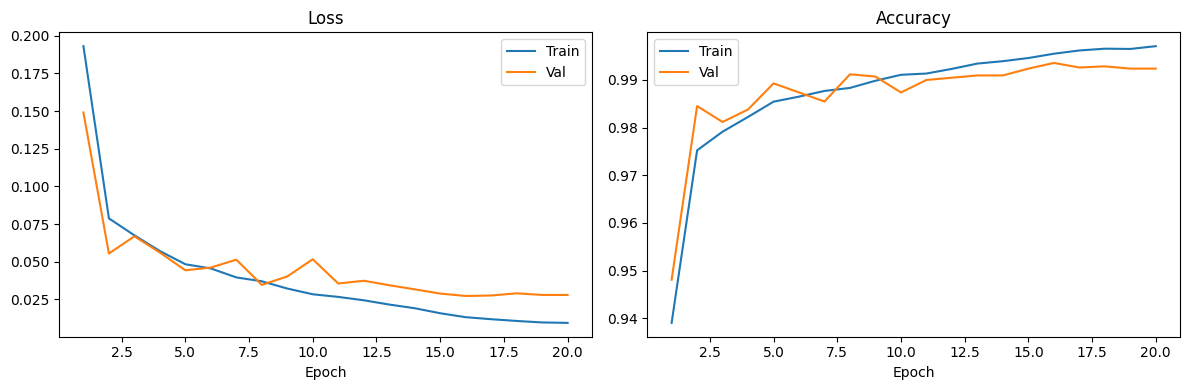

In [14]:
epochs = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train")
axes[0].plot(epochs, history["val_loss"],   label="Val")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train")
axes[1].plot(epochs, history["val_acc"],   label="Val")
axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Generate Submission

In [15]:
# Load the best checkpoint
model.load_state_dict(torch.load(best_model_path, map_location=DEVICE))
model.eval()

predictions = []
with torch.no_grad():
    for images in test_loader:
        images = images.to(DEVICE)
        outputs = model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        predictions.extend(preds)

submission = pd.DataFrame({
    "ImageId": range(1, len(predictions) + 1),
    "Label":   predictions,
})
submission.to_csv("submission.csv", index=False)
print(f"Submission saved: {len(submission)} rows")
submission.head()

Submission saved: 28000 rows


,ImageId,Label
0,1,2
1,2,0
2,3,9
3,4,0
4,5,3
